### gpu/spyglass setup

In [1]:
import os
import datajoint as dj
import numpy as np
import spyglass
import jax
import os

#before, make sure you are not conflicting with others
#run nvidia-smi on your ssh and determine which GPU you are going to occupy (spyglass can only use one GPU at a time)
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.99"
device_id = 1 # or whatever number GPU you want
device = jax.devices()[device_id]
jax.config.update("jax_default_device", device)


# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "decoding":
    os.chdir("..")
dj.config["enable_python_native_blobs"] = True
dj.config.load("dj_local_conf.json")  # load config for database connection info

print("Default device setting:", jax.default_backend())
print("Explicit device you picked:", device)
print(spyglass.__file__) # confirm your environment is set up correctly
print(spyglass.__version__) # confirm your spyglass version

[2026-03-24 00:04:05,397][INFO]: DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306
2026-03-24 00:04:08.888277: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 0 and 9; status: INTERNAL: failed to enable peer access from 0x7fd4788f8080 to 0x7fd4908f8b20: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-03-24 00:04:08.891368: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 1 and 9; status: INTERNAL: failed to enable peer access from 0x7fd4748f84d0 to 0x7fd4908f8b20: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-03-24 00:04:08.893998: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 2 and 9; status: INTERNAL: failed to enable peer access from 0x7fd47c883cf0 to 0x7fd4908f8b20: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhau

Default device setting: gpu
Explicit device you picked: gpu:1
/home/yshwang/code/spyglass/src/spyglass/__init__.py
0.5.5a2.dev43+g50be44655.d20260217


### File and Parameters

In [1]:
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
import spyglass.data_import as sgi
import spyglass.position as sgp
from spyglass.common import Nwbfile
from spyglass.spikesorting.v1.recording import SortGroup
from spyglass.decoding.v1.waveform_features import WaveformFeaturesParams
from spyglass.spikesorting.analysis.v1.group import UnitSelectionParams
from spyglass.decoding.v1.core import DecodingParameters

nwb_file_name =  "IM-1594_20230726_.nwb"
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
interval_list_name = "00_r1"
team_name = "Berke Lab and friends"

# parameters
preproc_param_name = "default" #"franklab_tetrode_hippocampus"
artifact_param_name = "ampl_1000_z_30_prop_075_1ms"
sorter = "mountainsort4"
sorter_param_name = "franklab_tetrode_hippocampus_30KHz"
waveform_param_name = "default_not_whitened"
metric_param_name = "franklab_default"
metric_curation_param_name = "default"
unit_filter_params_name = "default_exclusion"
#decoding_param_name = "contfrag_sorted_10chunks_v2" # What Eric used
decoding_param_name = "contfrag_sorted_50chunks_100blocks"
trodes_pos_params_name = "berke_double_led_decoding" # led1_is_front = 0, upsampling_sampling_rate = 500


ss_group_name = "sorted_spikes_group"
#pos_group_name = "1000uV_artifact_65uV_detection_custom_channels" # Some of yang-sun's position labeling was stupid. sorry!
pos_group_name = "sorted_spikes_pos_group"
# Optionally print them all!
review_params = False
if review_params:
    # Preprocessing
    display((sgs.SpikeSortingPreprocessingParameters() & {"preproc_param_name": preproc_param_name}).fetch1())
    display((sgs.ArtifactDetectionParameters() & {"artifact_param_name": artifact_param_name}).fetch1("artifact_params"))
    # Sorting
    display((sgs.SpikeSorterParameters() & {"sorter": sorter, "sorter_param_name": sorter_param_name}).fetch1())
    # Curation
    display((sgs.WaveformParameters() & {"waveform_param_name": waveform_param_name}).fetch1())
    display((sgs.MetricParameters() & {"metric_param_name": metric_param_name}).fetch1())
    display((sgs.MetricCurationParameters() & {"metric_curation_param_name": metric_curation_param_name}).fetch1())
    # Decoding
    display((UnitSelectionParams() & {"unit_filter_params_name": unit_filter_params_name}).fetch1())
    display((DecodingParameters() & {"decoding_param_name" : decoding_param_name}).fetch("decoding_params"))
    # Position (for decoding)
    display((sgp.v1.TrodesPosParams() & {"trodes_pos_params_name": trodes_pos_params_name}).fetch1("params"))

[2026-03-24 09:45:55,389][INFO]: DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306
[09:46:31][WARNING] Spyglass: File may already be a copy: IM-1594_20230726_.nwb


# First check out all existing entries for this nwb

Helpful if we're halfway through running this.

In [2]:
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
from spyglass.position import PositionOutput

# Find all entries for this nwb in PositionOutput
print(f"Entries for {nwb_file_name} in PositionOutput.TrodesPosV1")
display(PositionOutput.TrodesPosV1 & {"nwb_file_name": nwb_file_name})

# Find all entries for this nwb in SortGroup
print(f"Entries for {nwb_file_name} in sgs.SortGroup")
display((sgs.SortGroup & {"nwb_file_name": nwb_file_name}))

# Find all entries for this nwb in SpikeSortingRecordingSelection
print(
    f"Entries for {nwb_file_name} in sgs.SpikeSortingRecordingSelection (one per SortGroup, or more if we are trying multiple preprocessing params)"
)
display(sgs.SpikeSortingRecordingSelection() & {"nwb_file_name": nwb_file_name})

# Fetch the recording ids (there is one for each sort group)
recording_ids = (
    sgs.SpikeSortingRecordingSelection() & {"nwb_file_name": nwb_file_name}
).fetch("KEY")

# Use the recording_ids to get the preprocessed recording for each
print(f"Entries for {nwb_file_name} in sgs.SpikeSortingRecording (one per SortGroup)")
display(sgs.SpikeSortingRecording() & recording_ids)

# Get the detected artifact times for this recording
print(
    f"Entries for {nwb_file_name} in sgs.ArtifactDetectionSelection (one per recording_id)"
)
display(sgs.ArtifactDetectionSelection() & recording_ids)
artifact_ids = (sgs.ArtifactDetectionSelection() & recording_ids).fetch("KEY")

print(f"Entries for {nwb_file_name} in sgs.ArtifactDetection (one per recording_id)")
display(sgs.ArtifactDetection() & artifact_ids)

print(f"Entries for {nwb_file_name} in sgs.SpikeSortingSelection")
display(sgs.SpikeSortingSelection() & {"nwb_file_name": nwb_file_name})
sorting_ids = (sgs.SpikeSortingSelection() & {"nwb_file_name": nwb_file_name}).fetch(
    "KEY"
)

print(f"Entries for {nwb_file_name} in sgs.SpikeSorting")
display(sgs.SpikeSorting() & sorting_ids)

print(f"Entries for {nwb_file_name} in sgs.CurationV1")
display(sgs.CurationV1() & sorting_ids)

print(f"Entries for {nwb_file_name} in sgs.MetricCurationSelection")
display(sgs.MetricCurationSelection() & sorting_ids)

print(f"Entries for {nwb_file_name} in sgs.SpikeSortingOutput")
merge_ids = SpikeSortingOutput().get_restricted_merge_ids(
    key={"nwb_file_name": nwb_file_name}, as_dict=True
)
display(SpikeSortingOutput & merge_ids)

print(f"Entries for {nwb_file_name} in SortedSpikesGroup")
display(SortedSpikesGroup & {"nwb_file_name": nwb_file_name})

Entries for IM-1594_20230726_.nwb in PositionOutput.TrodesPosV1


merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
4508af95-a4cd-1099-b33c-f06ac503ec5e,IM-1594_20230726_.nwb,pos 0 valid times,berke_double_led_decoding
c6318171-7881-87f8-94ed-0957d1d866c9,IM-1594_20230726_.nwb,pos 0 valid times,berke_double_led


Entries for IM-1594_20230726_.nwb in sgs.SortGroup


nwb_file_name name of the NWB file,sort_group_id,sort_reference_electrode_id the electrode to use for referencing
IM-1594_20230726_.nwb,0,-1
IM-1594_20230726_.nwb,1,-1
IM-1594_20230726_.nwb,2,-1
IM-1594_20230726_.nwb,3,-1
IM-1594_20230726_.nwb,4,-1
IM-1594_20230726_.nwb,5,-1
IM-1594_20230726_.nwb,6,-1
IM-1594_20230726_.nwb,7,-1
IM-1594_20230726_.nwb,8,-1
IM-1594_20230726_.nwb,9,-1


Entries for IM-1594_20230726_.nwb in sgs.SpikeSortingRecordingSelection (one per SortGroup, or more if we are trying multiple preprocessing params)


...

Entries for IM-1594_20230726_.nwb in sgs.SpikeSortingOutput


[09:46:37][WARNING] Spyglass: V0 requires artifact restrict. Ignoring restrict_by_artifact


merge_id,source
0f119822-5884-d709-af80-cde6a6f078d1,CurationV1
1c92a840-7b6e-412a-1cae-f4a9c516a3d0,CurationV1
20cad657-0120-e16a-b481-eb7d11029f5a,CurationV1
2764ae69-af1d-aa53-8221-08ff55ce59d0,CurationV1
2cc87a0a-cd3d-68fb-654b-d9e87326b353,CurationV1
3383224d-34dd-a21a-d768-9503d3bdb01b,CurationV1
3469e1b8-aecc-fe31-1efc-0105fe19d3bd,CurationV1
4daca958-e4c8-6bd1-93f8-c4b29bbf0fe1,CurationV1
4eca21cd-2639-ac76-2a41-56fd9de22a1b,CurationV1
57656df5-3f32-5111-9686-33f0ee0335ec,CurationV1


Entries for IM-1594_20230726_.nwb in SortedSpikesGroup


nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
IM-1594_20230726_.nwb,default_exclusion,sorted_spikes_group


### Add modified decoding parameters if needed

In [4]:
from non_local_detector.models import ContFragSortedSpikesClassifier
from spyglass.decoding.v1.core import DecodingParameters

if False:
    decoding_param_name = "contfrag_sorted_50chunks_100blocks"

    # when I was trying to change the bin size
    # row = (DecodingParameters & {"decoding_param_name": "contfrag_sorted_10chunks_v2"}).fetch1()
    # p = row["decoding_params"]["environments"]
    # p[0].place_bin_size = 2.5
    # print(row)
    
    DecodingParameters.insert1(
        {
            "decoding_param_name": decoding_param_name,
            "decoding_params": ContFragSortedSpikesClassifier(
                                # environments = row["decoding_params"]["environments"],
                                sorted_spikes_algorithm_params={
                                "block_size": 100,
                                "position_std": 6.0,
                                },
                                ),
            "decoding_kwargs": {
                                "n_chunks": 50,
                                "cache_likelihood": False,
                                },
        },
        skip_duplicates=True,
    )
    
model_params = (
    DecodingParameters & {"decoding_param_name": decoding_param_name }
).fetch1()
display(ContFragSortedSpikesClassifier(**model_params["decoding_params"]))
display(DecodingParameters & {"decoding_param_name": decoding_param_name })

ContFragSortedSpikesClassifier(continuous_initial_conditions_types=[UniformInitialConditions(),
                                                                    UniformInitialConditions()],
                               continuous_transition_types=[[RandomWalk(environment_name='',
                                                                        movement_var=6.0,
                                                                        movement_mean=0.0,
                                                                        use_manifold_distance=False,
                                                                        direction=None),
                                                             Uniform(environment_name='',
                                                                     environment2_name=None)],
                                                            [Uniform(environment_name='',
                                                                     envir...
                               observation_models=[ObservationModel(environment_name='',
                                                                    encoding_group=0,
                                                                    is_local=False,
                                                                    is_no_spike=False),
                                                   ObservationModel(environment_name='',
                                                                    encoding_group=0,
                                                                    is_local=False,
                                                                    is_no_spike=False)],
                               sampling_frequency=500,
                               sorted_spikes_algorithm='sorted_spikes_kde',
                               sorted_spikes_algorithm_params={'block_size': 100,
                                                               'position_std': 6.0},
                               state_names=['Continuous', 'Fragmented'])

decoding_param_name a name for this set of parameters,decoding_params initialization parameters for model,decoding_kwargs additional keyword arguments
contfrag_sorted_50chunks_100blocks,=BLOB=,=BLOB=


### Selection key for decoder output

In [4]:
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.decoding import SortedSpikesDecodingSelection
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
import spyglass.spikesorting.v1 as sgs

selection_key = {
    "sorted_spikes_group_name": ss_group_name,
    "unit_filter_params_name": unit_filter_params_name,
    "position_group_name": pos_group_name,
    "decoding_param_name": decoding_param_name,
    "nwb_file_name": nwb_file_name,
    "encoding_interval": "00_r1", # to encode using the entire session, this is always our interval list name
    "decoding_interval": "00_r1",
    "estimate_decoding_params": True, # False will make error. Keep it True
}

SortedSpikesDecodingSelection.insert1(
    selection_key,
    skip_duplicates=True,
)

display(SortedSpikesDecodingSelection & {"nwb_file_name": nwb_file_name})
display(SortedSpikesDecodingSelection & selection_key)

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
IM-1594_20230726_.nwb,default_exclusion,sorted_spikes_group,sorted_spikes_pos_group,contfrag_sorted,00_r1,00_r1,1
IM-1594_20230726_.nwb,default_exclusion,sorted_spikes_group,sorted_spikes_pos_group,contfrag_sorted_50chunks_100blocks,00_r1,00_r1,1


nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
IM-1594_20230726_.nwb,default_exclusion,sorted_spikes_group,sorted_spikes_pos_group,contfrag_sorted_50chunks_100blocks,00_r1,00_r1,1


### Run decoder. This will run the decoding and insert the results into the database. We can then retrieve the results from the database.

In [5]:
from spyglass.decoding.v1.sorted_spikes import SortedSpikesDecodingV1

decoding_entry = (SortedSpikesDecodingV1 & selection_key)

# Run the decoding if we don't have output yet
if len(decoding_entry.fetch()) == 0:
    SortedSpikesDecodingV1.populate(selection_key)
else:
    print("Decoding entry already exists!")


[09:47:46][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
/home/yshwang/code/spyglass/src/spyglass/decoding/v1/core.py:313: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  position_df[column]

Encoding models:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

...

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/188 [00:00<?, ?cell/s]

/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/non_local_detector/models/base.py:1126: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'state_bins' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  results = xr.Dataset(


### Evaluate the result

In [6]:
# 1 fetch the decoding results
 
from spyglass.decoding.v1.sorted_spikes import SortedSpikesDecodingV1

display(SortedSpikesDecodingV1 & selection_key)
decoding_results = (SortedSpikesDecodingV1 & selection_key).fetch_results()
decoding_results

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters,results_path path to the results file,classifier_path path to the classifier file
IM-1594_20230726_.nwb,default_exclusion,sorted_spikes_group,sorted_spikes_pos_group,contfrag_sorted_50chunks_100blocks,00_r1,00_r1,1,=BLOB=,=BLOB=


[2026-03-24 14:16:52,970][WARNING]: Skipped checksum for file with hash: 5053eb59-117e-05e5-f117-8c5bf017e040, and path: /stelmo/nwb/analysis/IM-1594_20230726/IM-1594_20230726_9fdbdb28-440b-47ce-9e50-3e46b4910a37.nc


<xarray.Dataset> Size: 192GB
Dimensions:                      (time: 3294666, state_bins: 14560, states: 2,
                                  state_ind: 14560, states_from: 2, states_to: 2)
Coordinates:
  * time                         (time) float64 26MB 11.99 11.99 ... 6.601e+03
    interval_labels              (time) int32 13MB ...
  * state_ind                    (state_ind) int32 58kB 0 0 0 0 0 ... 1 1 1 1 1
  * states                       (states) object 16B 'Continuous' 'Fragmented'
  * states_from                  (states_from) object 16B 'Continuous' 'Fragm...
  * states_to                    (states_to) object 16B 'Continuous' 'Fragmen...
    environments                 (states) object 16B ...
    encoding_groups              (states) int32 8B ...
  * state_bins                   (state_bins) object 116kB MultiIndex
  * state                        (state_bins) object 116kB 'Continuous' ... '...
  * x_position                   (state_bins) float64 116kB 46.5 46.5 ... 226.1
  * y_position                   (state_bins) float64 116kB 40.95 ... 198.4
Data variables:
    acausal_posterior            (time, state_bins) float32 192GB ...
    acausal_state_probabilities  (time, states) float32 26MB ...
    initial_conditions           (state_bins) float64 116kB ...
    discrete_state_transitions   (states_from, states_to) float64 32B ...
Attributes:
    marginal_log_likelihoods:  [-34345708. -34302344. -34300312.]

In [ ]:
# 2 generate the interactive figurl visualization. Consider figpack.view package if you want to do more custom visualization.
from spyglass.decoding.decoding_merge import DecodingOutput

from non_local_detector.model_checking import (
    get_highest_posterior_threshold,
    get_HPD_spatial_coverage,
)
from non_local_detector.visualization import (
    create_interactive_2D_decoding_figurl,
)

(
    position_info,
    position_variable_names,
) = SortedSpikesDecodingV1.fetch_position_info(selection_key)
#results_time = decoding_results.acausal_posterior.isel(intervals=0).time.values
#results_time = decoding_results.time.values #isel(intervals=0).time.values # from stephs
results_time = decoding_results.acausal_posterior.time.values
position_info = position_info.loc[results_time[0] : results_time[-1]]

env = SortedSpikesDecodingV1.fetch_environments(selection_key)[0]
# spike_times, _ = SortedSpikesDecodingV1.fetch_spike_data(selection_key)
spike_times = SortedSpikesDecodingV1.fetch_spike_data(selection_key) # from stephs

create_interactive_2D_decoding_figurl(
    position_time=position_info.index.to_numpy(),
    position=position_info[position_variable_names],
    env=env,
    results=decoding_results,
    # posterior=decoding_results.acausal_posterior.isel(intervals=0)
    # .unstack("state_bins")
    # .sum("state")
    posterior=decoding_results.acausal_posterior
    .unstack("state_bins")
    .sum("state"),
    spike_times=spike_times,
    head_dir=position_info["orientation"],
    speed=position_info["speed"],
)

[14:11:43][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
[14:11:47][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


[2026-02-20 17:11:01,069][WARNING]: Skipped checksum for file with hash: 207e9873-c025-c70a-4286-65cfc8d53911, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_250b1882-ab0c-4400-9ffd-56d75eb56234.pkl


(102, 6048)
(102, 84, 72)


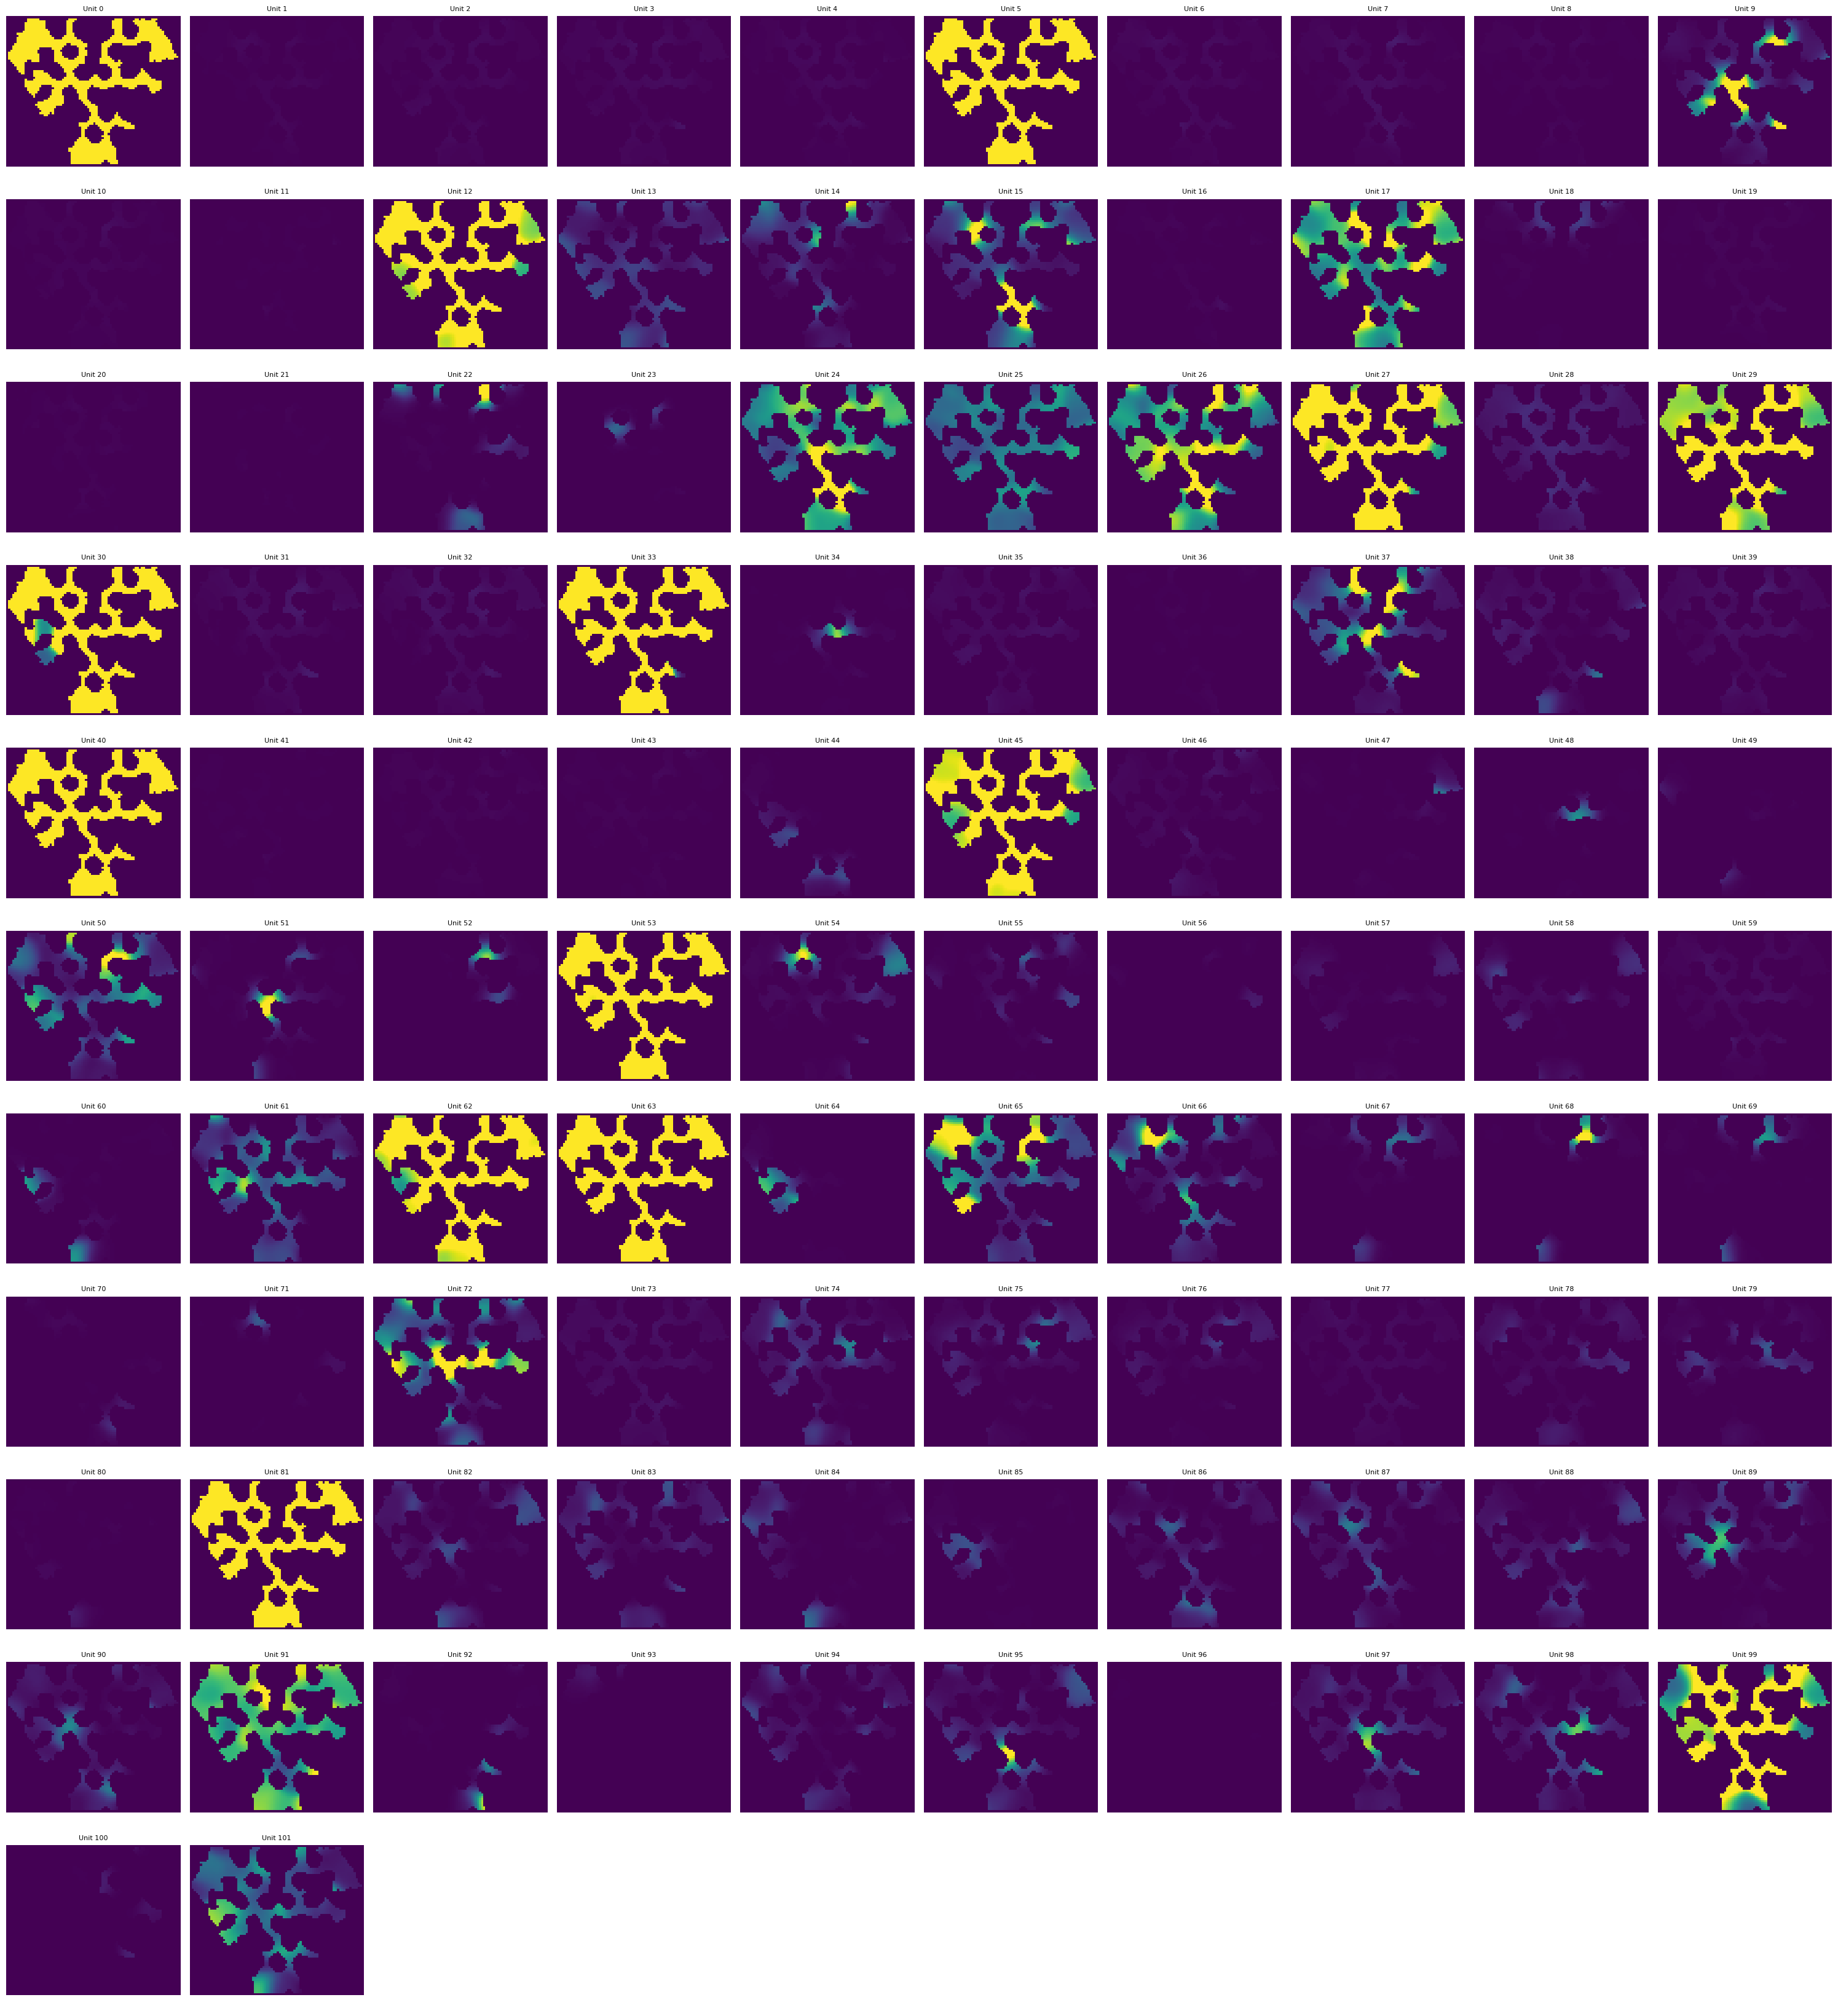

In [8]:
from spyglass.decoding.decoding_merge import DecodingOutput
import matplotlib.pyplot as plt

max_firing_rate = 15  # spikes/s
show_colorbar = False

# Fetch classifier
classifier = (SortedSpikesDecodingV1 & selection_key).fetch_model()
fs = classifier.sampling_frequency

# Fetch place fields and reshape
place_fields = classifier.encoding_model_[("", 0)]["place_fields"]  # units, place_bins
print(place_fields.shape)
place_fields = place_fields.reshape(
    (-1, *classifier.environments[0].centers_shape_)
)  # units, x, y
print(place_fields.shape)

# Set up subplots
n_units = place_fields.shape[0]

n_cols = 10  # number of columns in the grid
n_rows = int(np.ceil(n_units / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

# Plot the place field for each unit
mappable = None
for i in range(n_units):
    ax = axes.flat[i]
    m = ax.pcolormesh(
        classifier.environments[0].edges_[0],
        classifier.environments[0].edges_[1],
        place_fields[i].T * fs,
        vmin=0,
        vmax=max_firing_rate,
    )

    # Optional add colorbar
    if show_colorbar:
        fig.colorbar(m, ax=ax, label="spikes/s")

    ax.set_title(f"Unit {i}", fontsize=8)
    ax.set_aspect("equal")
    ax.set_axis_off()

# Turn off any unused subplots
for j in range(n_units, n_rows * n_cols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()

### 1. Position heatmap

In [ ]:
# 2 generate the interactive figurl visualization. Consider figpack.view package if you want to do more custom visualization.
# 
# 
from spyglass.position import PositionOutput

# firstm, find merge id from TrodesPosSelection


trodes_s_key = {
    "nwb_file_name": nwb_copy_file_name,
    "interval_list_name": "pos 0 valid times",
    "trodes_pos_params_name": trodes_pos_params_name,
}

PositionOutput.TrodesPosV1 & trodes_s_key

merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
d931de2e-09f2-de2c-2c9b-8fc8f54eb3d1,IM-1478_20220725_.nwb,pos 0 valid times,berke_double_led_decoding


merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
b8f5b7ed-dcc4-9ab5-38cc-7c6e67e2c09a,IM-1594_20230725_.nwb,pos 0 valid times,berke_double_led_decoding


[15:25:34][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


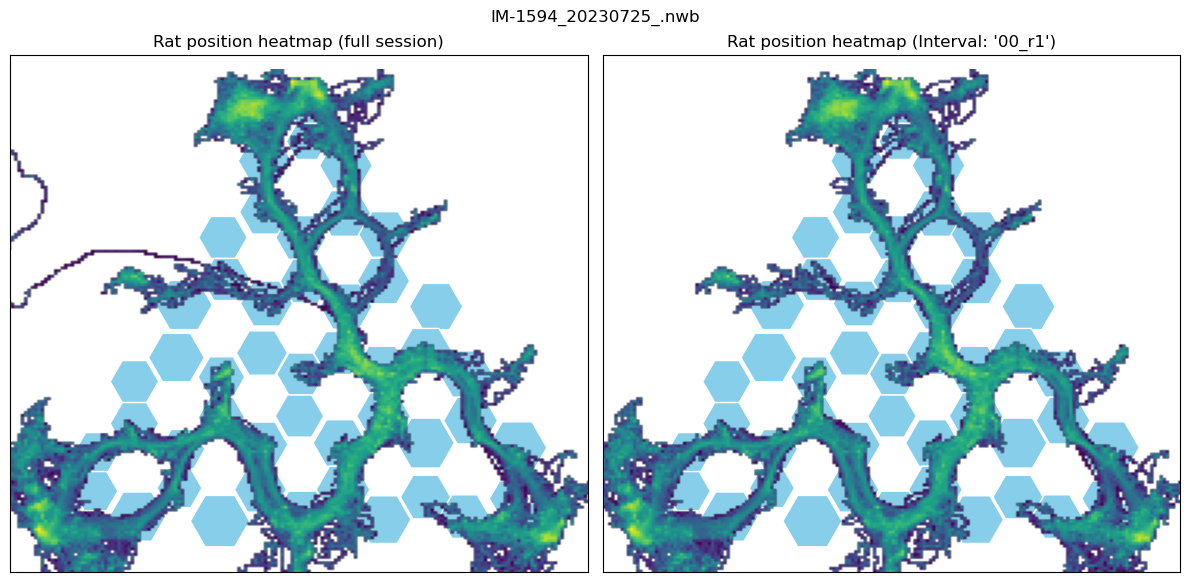

In [3]:
from spyglass.position import PositionOutput
from hex_maze_behavior import HexMazeBlock, HexCentroids
from hexmaze import plot_hex_maze
import matplotlib.pyplot as plt
import numpy as np

# Grab a key from the output above for now
# Use this merge id to restrict the PositionOutput table and fetch the position data
nwb_copy_file_name = 'IM-1594_20230725_.nwb'
interval_list_name = '00_r1'
trodes_pos_params_name = "berke_double_led_decoding"

trodes_s_key = {
    "nwb_file_name": nwb_copy_file_name,
    "interval_list_name": "pos 0 valid times",
    "trodes_pos_params_name": trodes_pos_params_name,
}

display(PositionOutput.TrodesPosV1 & trodes_s_key)

key = {
    'nwb_file_name': nwb_copy_file_name, 
    'merge_id': str((PositionOutput.TrodesPosV1 & trodes_s_key).fetch1('merge_id'))
}


# Fetch processed position data for this epoch (remove nan)
position_df = (PositionOutput & key).fetch1_dataframe()
position_df = position_df.dropna(subset=['position_x', 'position_y'])

# Restrict the position data to '00_r1' interval
valid_times = (sgc.IntervalList() & {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': interval_list_name}).fetch1('valid_times')[0]
position_df_interval = position_df.loc[(position_df.index >= valid_times[0]) & (position_df.index <= valid_times[1])]

# Get the hex centroids for this session for plotting the hexes in the right places
centroids_dict = HexCentroids().get_hex_centroids_dict_cm(key)
# Remove side hex centroids (plotting expects exactly 49 integer centroids)
centroids_dict = {int(k): v for k, v in centroids_dict.items() if "_left" not in k and "_right" not in k}

# Plot rat position heatmap for the full epoch
fig_full, ax_full = plt.subplots(1, 2, figsize=(12, 6))

# Full Session: Create 2D histogram (aka heatmap) of the rat's x, y positions
heatmap_full, xedges, yedges = np.histogram2d(
    position_df['position_x'].values, position_df['position_y'].values, bins=200
)
heatmap_full_masked = np.ma.masked_where(heatmap_full == 0, heatmap_full)
log_heatmap_full = np.log1p(heatmap_full_masked)

# Plot maze layout (open hexes only) using custom centroids if they exist
if centroids_dict is not None:
    plot_hex_maze(
        barriers=None, centroids=centroids_dict, ax=ax_full[0], show_hex_labels=False,
        show_barriers=False, show_choice_points=False, invert_yaxis=True
    )
# Plot rat position heatmap on top of the hexes
ax_full[0].imshow(
    log_heatmap_full.T, origin='lower', cmap='viridis',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='equal', zorder=1
)
ax_full[0].set_xticks([])
ax_full[0].set_yticks([])
ax_full[0].set_title(f"Rat position heatmap (full session)")

# Interval Session: Create 2D histogram (aka heatmap) of the rat's x, y positions
heatmap_interval, xedges_interval, yedges_interval = np.histogram2d(
    position_df_interval['position_x'].values, position_df_interval['position_y'].values, bins=200
)
heatmap_interval_masked = np.ma.masked_where(heatmap_interval == 0, heatmap_interval)
log_heatmap_interval = np.log1p(heatmap_interval_masked)

if centroids_dict is not None:
    plot_hex_maze(
        barriers=None, centroids=centroids_dict, ax=ax_full[1], show_hex_labels=False,
        show_barriers=False, show_choice_points=False, invert_yaxis=True
    )
ax_full[1].imshow(
    log_heatmap_interval.T, origin='lower', cmap='viridis',
    extent=[xedges_interval[0], xedges_interval[-1], yedges_interval[0], yedges_interval[-1]],
    aspect='equal', zorder=1
)
ax_full[1].set_xticks([])
ax_full[1].set_yticks([])
ax_full[1].set_title(f"Rat position heatmap (Interval: '{interval_list_name}')")

fig_full.suptitle(nwb_copy_file_name)
fig_full.tight_layout()
fig_full.show()

In [12]:
DecodingOutput.ClusterlessDecodingV1 & selection_key
DecodingOutput.ClusterlessDecodingV1 & {'decoding_interval': 'epoch0_block1'}

merge_id,nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
283b3c6a-a51c-1369-6624-2185c169a39d,IM-1478_20220724_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1
4e1f4ceb-11b5-837c-16a8-e0ac5b49471b,IM-1478_20220725_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1
576a94e6-871e-87a2-7b33-d684d79853cc,IM-1871_20250801_.nwb,ampl1000_amplitude_500uV,ampl1000_amplitude_500uV,contfrag_clusterless_252ch_4chunks_2000block_3bin,epoch0_block1,epoch0_block1,1


### Figurl Generator

In [14]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingSelection
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1
from non_local_detector.visualization import (
    create_interactive_2D_decoding_figurl,
)

selection_key = {
    "waveform_features_group_name": waveform_features_group_name,
    "position_group_name": waveform_features_group_name,
    "decoding_param_name": decoding_param_name,
    "nwb_file_name": "IM-1478_20220724_.nwb",
    "encoding_interval": "00_r1",
    "decoding_interval": "epoch0_block1",
    "estimate_decoding_params": True,
}

display(ClusterlessDecodingSelection & selection_key)


decoding_results = (ClusterlessDecodingV1 & selection_key).fetch_results()
(
    position_info,
    position_variable_names,
) = ClusterlessDecodingV1.fetch_position_info(selection_key)

results_time = decoding_results.acausal_posterior.time.values
position_info = position_info.loc[results_time[0] : results_time[-1]]

env = ClusterlessDecodingV1.fetch_environments(selection_key)[0]
spike_times, _ = ClusterlessDecodingV1.fetch_spike_data(selection_key)

create_interactive_2D_decoding_figurl(
    position_time=position_info.index.to_numpy(),
    position=position_info[position_variable_names],
    env=env,
    results=decoding_results,
    posterior=decoding_results.acausal_posterior
    .unstack("state_bins")
    .sum("state"),
    spike_times=spike_times,
    head_dir=position_info["orientation"],
    speed=position_info["speed"],
)

nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
IM-1478_20220724_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1


[2026-01-19 17:32:25,221][WARNING]: Skipped checksum for file with hash: 876fb688-59d1-0141-bbbc-6e5ad792d1a7, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_54f63b25-27ea-49de-9a5d-7f1e14ce4bb2.nc
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  warnings.warn(
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than onc

Computing sha1 of /stelmo/nwb/kachery_storage/tmp_NqKLaGW9/file.dat


'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=sha1://589b04c1448cbb2489dd7345a1af359256907458&label=2D%20Decoding&zone=franklab.default'

## Decoder output evaluation
- place field mapping!